# Detecting Privacy-Sensitive Prompts Before They Reach an External LLM

### A comparison of purpose-built classifiers and a general-purpose LLM baseline

**Team:** Alan Jiang, Aura Gaines, Brandon Shumack, Fil Dziembowski  
**Course:** CYBER 207: AI/ML in Cybersecurity. Summer 2026.

**Professor:** Dr. Nahid Farhady

Employees increasingly use external large language models for writing, coding, and research. A prompt can therefore become a new path for accidental disclosure: personally identifiable information may leave an organization's controlled environment before a security team is aware of it.

This project tests whether a model can screen prompt text before submission. We compare lightweight classical models, a multilayer perceptron, multilingual DistilBERT, and a locally hosted Phi-4 baseline.


### How to use this notebook

This is the primary project notebook and the starting point for the submission. It explains the full experiment, connects the major project decisions to the research question, and presents the main results and conclusions.

Open this notebook in Google Colab, then select Runtime → Run all. The cells should run in order from top to bottom. The code loads the final project metadata and generates the central tables and figures. The supporting notebooks contain the detailed EDA, feature engineering, model training, tuning, and evaluation workflows.

In [1]:
# Primary-notebook setup: locate or clone the project repo, then import
# only the lightweight packages used for summary tables and figures.
import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", None)

REPO_URL = "https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison.git"
REPO_NAME = "cyber207_specialized_PII_detection_comparison"
FINAL_REPO_REF = "main"


def locate_repo_root():
    # Use the current repo when available; otherwise clone the final branch.
    check = subprocess.run(
        ["git", "rev-parse", "--show-toplevel"],
        capture_output=True,
        text=True,
    )
    if check.returncode == 0:
        return Path(check.stdout.strip())

    base_dir = Path("/content") if "google.colab" in sys.modules else Path.cwd()
    repo_dir = base_dir / REPO_NAME
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", FINAL_REPO_REF, REPO_URL, str(repo_dir)],
            check=True,
        )
    return repo_dir


repo_root = locate_repo_root()
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Primary notebook setup complete")
print("Repository root:", repo_root)

Primary notebook setup complete
Repository root: /content/cyber207_specialized_PII_detection_comparison


## 1. Background and Motivation

External LLMs can improve productivity, but they also create a privacy and security problem. A user may paste a name, email address, phone number, account number, or other identifier into a prompt without recognizing that the information is leaving the organization's direct control. Traditional controls may detect some structured identifiers, but prompt text can be multilingual, informal, and context dependent.

We investigate a preventive control: classify the text locally before it is sent. The detector does not replace data governance or access controls. Instead, it could provide a warning or block a prompt when the text appears to contain PII.

The practical question is not only whether this is possible, but also how much model complexity the task requires. A small purpose-built classifier may be easier to run locally than a general-purpose LLM, while a fine-tuned transformer may capture context that sparse text features miss.

## 2. Dataset-Inspired Project Direction

The project direction emerged from the AI4Privacy PII-Masking-400k dataset. The source dataset provides multilingual text examples with token-level PII annotations. Rather than train a named-entity recognition system, we collapsed those annotations into one document-level decision:

- **Safe (`0`)**: every token is labeled `O`, meaning the dataset marks no PII.
- **Privacy-sensitive (`1`)**: at least one token has a PII label.

This reframing matches the intended screening decision: should the prompt be allowed to continue, or should it be flagged before submission?

We then compared two broad approaches. The first used models trained specifically on this dataset, ranging from classical classifiers to multilingual DistilBERT. The second used Phi-4 as an instruction-prompted general-purpose LLM baseline. This keeps the specialized classifier as the core experiment while providing a useful comparison with a larger generic model.


## 3. Research Question

How accurately and efficiently can specialized machine learning models classify text as safe or privacy-sensitive before it is submitted to an external LLM, and how do their detection performance and response times compare with a general-purpose LLM baseline?


## 4. Hypothesis

We expected models trained specifically for this binary classification task to outperform the prompted Phi-4 baseline in both PII detection and response time. We also expected multilingual DistilBERT to provide the strongest detection performance because it can learn contextual patterns across the dataset’s languages, while the classical models would offer faster, lower-complexity alternatives.

The hypothesis would be supported if the specialized models achieved stronger held-out PII recall and F1 while operating quickly enough for interactive prompt screening, without relying on label-derived inputs.

## 5. Problem Definition

We treat the project as binary document classification:

| Label | Meaning | Screening action |
|---|---|---|
| `0` | Safe: no dataset-annotated PII | Allow or continue normal processing |
| `1` | Privacy-sensitive: at least one dataset-annotated PII token | Warn, block, or request review |

The model receives only the text available at screening time. Token labels, privacy masks, and other answer-derived annotations are excluded from the model features because using them would create data leakage.

For this project, **privacy-sensitive** has a specific operational meaning: the text contains PII according to the dataset annotations. The classifier does not detect every form of sensitive organizational information, such as source code, trade secrets, credentials, or confidential strategy.

False negatives are the highest-risk error because they allow PII to pass undetected. False positives also matter, however, because excessive blocking would make a real screening tool difficult to use.


## 6. Dataset Description

We used the **AI4Privacy PII-Masking-400k** dataset. The original working split contained 325,517 rows. EDA identified six blank-text rows and 93 duplicate text rows after the first occurrence. Because some blank rows were also duplicated, removing blanks and then exact duplicates removed 94 rows total.

The final cleaned dataset contains **325,423 examples**:

- **219,260 privacy-sensitive examples (67.4%)**
- **106,163 safe examples (32.6%)**

Using seed 42, we created a stratified 80/10/10 split. Cleaning occurred before splitting, and the final overlap check found no duplicate text shared across train, validation, and test.


In [2]:
# Load the authoritative cleaned counts instead of retyping them in 00.
metadata_path = repo_root / "data_splits" / "split_metadata.json"
with metadata_path.open() as f:
    split_metadata = json.load(f)

balance = split_metadata["class_balance"]
dataset_summary = pd.DataFrame([
    {
        "Split": "Train",
        "Examples": split_metadata["train_size"],
        "Privacy-sensitive": balance["train"]["sensitive"],
        "Safe": balance["train"]["safe"],
    },
    {
        "Split": "Validation",
        "Examples": split_metadata["val_size"],
        "Privacy-sensitive": balance["val"]["sensitive"],
        "Safe": balance["val"]["safe"],
    },
    {
        "Split": "Test",
        "Examples": split_metadata["test_size"],
        "Privacy-sensitive": balance["test"]["sensitive"],
        "Safe": balance["test"]["safe"],
    },
])

dataset_summary.loc[len(dataset_summary)] = {
    "Split": "Total",
    "Examples": dataset_summary["Examples"].sum(),
    "Privacy-sensitive": dataset_summary["Privacy-sensitive"].sum(),
    "Safe": dataset_summary["Safe"].sum(),
}
dataset_summary["Sensitive %"] = (
    dataset_summary["Privacy-sensitive"] / dataset_summary["Examples"] * 100
).round(1)

assert dataset_summary.iloc[-1]["Examples"] == split_metadata["total_examples"] == 325423
assert all(value == 0 for value in split_metadata["split_overlap_check"].values())
display(dataset_summary)

,Split,Examples,Privacy-sensitive,Safe,Sensitive %
0,Train,260338,175408,84930,67.4
1,Validation,32542,21926,10616,67.4
2,Test,32543,21926,10617,67.4
3,Total,325423,219260,106163,67.4


The saved modeling columns are `text`, `label`, and `original_index`. The index allows later error analysis against the original annotations, but it is not used as a predictive feature.

Full data inspection and the cleaning rationale are documented in [01 Data EDA](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/01_data_eda.ipynb). The cleaned split counts above are loaded directly from `data_splits/split_metadata.json`, the authoritative metadata used by the modeling pipeline.

## 7. Exploratory Data Analysis

EDA was used to test whether the dataset and label conversion were suitable before modeling. The most important findings were:

- The original data contained no null text in the working columns, but it contained six blank strings.
- Exact duplicates created a small cross-split leakage risk in the initial split. Cleaning before resplitting removed that overlap.
- Privacy-sensitive examples were slightly longer on average: about 157 characters and 19.8 words, compared with 133 characters and 17.5 words for safe examples.
- HTML-like formatting appeared in both classes but was more common in privacy-sensitive examples, so models may learn formatting as well as PII content.
- Bracketed placeholder tokens appeared in both classes and were more common in the safe class. Their presence alone therefore does not determine the label.
- The class distribution is moderately imbalanced, making accuracy insufficient as the only evaluation metric.

These findings influenced the final workflow: clean before splitting, keep the split stratified, prohibit label-derived features, include structural and privacy-pattern features, and evaluate PII precision, recall, and F1 in addition to accuracy.

In [3]:
# summarize the EDA findings that changed the modeling workflow
eda_summary = pd.DataFrame(
    [
        ["Blank text", "6 rows", "Removed before the final split"],
        ["Exact duplicate text", "93 identified initially; 88 remained after blank removal", "Removed before the final split"],
        ["Class balance", "67.4% sensitive / 32.6% safe", "Use stratification and class-aware metrics"],
        ["Text length", "Sensitive text was slightly longer", "Treat length as a supporting feature only"],
        ["HTML-like formatting", "Present in both classes; more common in class 1", "Document possible formatting artifact"],
        ["Placeholder tokens", "Present in both classes", "Do not treat placeholder shape as the label"],
    ],
    columns=["EDA check", "Finding", "Project response"],
)
display(eda_summary)

,EDA check,Finding,Project response
0,Blank text,6 rows,Removed before the final split
1,Exact duplicate text,93 identified initially; 88 remained after bla...,Removed before the final split
2,Class balance,67.4% sensitive / 32.6% safe,Use stratification and class-aware metrics
3,Text length,Sensitive text was slightly longer,Treat length as a supporting feature only
4,HTML-like formatting,Present in both classes; more common in class 1,Document possible formatting artifact
5,Placeholder tokens,Present in both classes,Do not treat placeholder shape as the label


## 8. Evaluation Strategy

All trainable transformations and models are fit on the training split. Hyperparameters, checkpoints, and decision thresholds are selected with the validation split. The held-out test split is reserved for final evaluation.

Each model uses the operating point selected for that model. Logistic Regression, Naive Bayes, and Linear SVM use validation thresholds chosen to maximize PII F1. The MLP uses a recall-focused threshold of 0.02 selected after validation analysis. DistilBERT retains its default argmax decision because performance changed negligibly across its validation sweep. Phi-4 does not use a numeric threshold; it classifies a document as PII whenever it returns one or more entities. The specialized-model operating points were fixed before final test evaluation.

We report:

- **PII precision:** when the model flags PII, how often it is correct.
- **PII recall:** how much of the true PII the model catches.
- **PII F1:** the balance between PII precision and recall.
- **Macro F1:** the average F1 across the safe and PII classes, giving both classes equal weight.
- **Accuracy:** the overall fraction classified correctly.
- **Confusion matrix and false-negative count:** the specific errors behind the summary scores.

PII recall is the primary security concern, but it cannot be interpreted alone. An always-predict-PII baseline achieves perfect PII recall while incorrectly blocking every safe example. PII F1, macro F1, accuracy, and the confusion matrix show whether higher recall comes at an unusable false-positive cost.

The classical models, neural network, and DistilBERT are evaluated on the full cleaned test set of 32,543 rows. Phi-4 is evaluated on a stratified 3,000-row subset drawn from that test set because local LLM inference is substantially slower. Its results are therefore directionally informative, but not perfectly comparable with full-test results.

In [4]:
# display the evaluation measures and their role in the project
metric_summary = pd.DataFrame(
    [
        ["PII recall", "PII detected / all true PII", "Measures sensitive prompts missed"],
        ["PII precision", "Correct PII flags / all PII flags", "Measures unnecessary blocking"],
        ["PII F1", "Harmonic mean of PII precision and recall", "Primary balanced PII score"],
        ["Macro F1", "Average F1 across both classes", "Prevents the majority class from dominating"],
        ["Accuracy", "Correct predictions / all predictions", "Useful context, but not sufficient alone"],
        ["Confusion matrix", "Counts of TP, TN, FP, and FN", "Shows the operational error tradeoff"],
    ],
    columns=["Measure", "Meaning", "Why we use it"],
)
display(metric_summary)

,Measure,Meaning,Why we use it
0,PII recall,PII detected / all true PII,Measures sensitive prompts missed
1,PII precision,Correct PII flags / all PII flags,Measures unnecessary blocking
2,PII F1,Harmonic mean of PII precision and recall,Primary balanced PII score
3,Macro F1,Average F1 across both classes,Prevents the majority class from dominating
4,Accuracy,Correct predictions / all predictions,"Useful context, but not sufficient alone"
5,Confusion matrix,"Counts of TP, TN, FP, and FN",Shows the operational error tradeoff


## 9. Feature Engineering

The classical and neural approaches require numeric representations of the prompt text. We created four feature sets:

| Feature set | Configuration | Purpose |
|---|---|---|
| TF-IDF | Up to 50,000 lowercase unigram and bigram features, `min_df=2` | Capture words and short phrases |
| Basic text | 10 numeric features | Capture length, digits, capitalization, punctuation, whitespace, and HTML-like structure |
| Privacy patterns | 8 binary regex features | Capture email, phone, URL, IP, date, long-number, address-word, and ID-word patterns |
| Combined | 50,018 total features | Join TF-IDF with the text and pattern blocks |

TF-IDF vocabulary construction and both numeric scalers are fit on the training split only. The validation and test sets are transformed with those training-fitted objects. The numeric blocks use `MinMaxScaler` before sparse concatenation so their raw magnitudes do not overwhelm the TF-IDF values.

These features are intentionally based only on the prompt text. The feature pipeline does not use token labels, privacy masks, original PII categories, or any other field that reveals the correct answer.

Full implementation and saved feature artifacts are documented in [02 Feature Engineering](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/02_feature_engineering.ipynb).


In [5]:
# Validate the repo feature functions without rebuilding the full matrices.
from src.features.text_features import extract_text_features
from src.features.pattern_features import extract_pattern_features

probe_text = pd.Series(["Contact example@example.com on 2026-01-15."])
text_feature_count = extract_text_features(probe_text).shape[1]
pattern_feature_count = extract_pattern_features(probe_text).shape[1]
tfidf_feature_count = 50000

feature_summary = pd.DataFrame(
    {
        "Feature set": ["TF-IDF", "Basic text", "Privacy patterns", "Combined"],
        "Number of features": [
            tfidf_feature_count,
            text_feature_count,
            pattern_feature_count,
            tfidf_feature_count + text_feature_count + pattern_feature_count,
        ],
        "Fit on training only": ["Yes", "Scaler", "Scaler", "Yes"],
    }
)
assert text_feature_count == 10
assert pattern_feature_count == 8
assert feature_summary.iloc[-1]["Number of features"] == 50018
display(feature_summary)

,Feature set,Number of features,Fit on training only
0,TF-IDF,50000,Yes
1,Basic text,10,Scaler
2,Privacy patterns,8,Scaler
3,Combined,50018,Yes


### 9.1 Feature-Set Ablation

To determine how much each feature block contributed, we conducted a controlled ablation study. Logistic Regression models with the same configuration were trained separately on each individual feature block and on the full combined matrix. Each model received its own validation-selected threshold for maximizing PII F1 and was then evaluated on the held-out test set.

The Combined row is the canonical Logistic Regression result reported in the main comparison table, so the values match exactly. The patterns-only model produced a degenerate result: its selected threshold classified every sample as PII. This achieved perfect recall but reduced precision to approximately the proportion of PII samples in the test set. The result shows that the eight binary pattern flags are not sufficiently discriminative alone and are more useful when combined with vocabulary-based features.

The full ablation procedure and results are available in [03 Classical Models](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/03_classical_models.ipynb).


In [ ]:
# feature-set ablation results (produced by 03_classical_models.ipynb)
ablation_path = repo_root / "results" / "feature_ablation.csv"
if ablation_path.exists():
    ablation = pd.read_csv(ablation_path)
    display(ablation)
    _comb = ablation.set_index("feature_set")
    _combined_key = next((k for k in _comb.index if k.startswith("Combined")), None)
    if _combined_key and "TF-IDF Only" in _comb.index:
        lift = _comb.loc[_combined_key, "test_pii_f1"] - _comb.loc["TF-IDF Only", "test_pii_f1"]
        print(f"Engineered text+pattern blocks add {lift:+.4f} test PII F1 over TF-IDF alone "
              f"(FN {int(_comb.loc['TF-IDF Only', 'test_fn'])} -> {int(_comb.loc[_combined_key, 'test_fn'])}).")
else:
    print("results/feature_ablation.csv not found, run the Feature-Set Ablation section of")
    print("03_classical_models.ipynb once to generate it; this cell then renders the comparison.")


,feature_set,n_features,val_threshold,test_pii_precision,test_pii_recall,test_pii_f1,test_macro_f1,test_fn,test_fp
0,TF-IDF only,50000,0.4293,0.8329,0.9058,0.8678,0.7773,2066,3984
1,Text features only,10,0.4609,0.6944,0.9683,0.8088,0.5054,694,9346
2,Patterns only,8,0.5063,0.6738,1.0000,0.8051,0.4026,0,10616
3,Combined (canonical LR),50018,0.4159,0.8478,0.9160,0.8806,0.8004,1841,3605


Engineered text+pattern blocks add +0.0128 test PII F1 over TF-IDF alone (FN 2066 -> 1841).


## 10. Models and Methods

We compared four modeling approaches to evaluate the tradeoffs among detection quality, false alarms, computational complexity, and response time. These included classical classifiers, a multilayer perceptron, multilingual DistilBERT, and a locally hosted Phi-4 baseline.

### 10.1 Baseline and Classical Models

We evaluated an always-predict-PII baseline and three classical classifiers: Logistic Regression, Multinomial Naive Bayes, and Linear SVM. The baseline demonstrates why recall cannot be considered alone. It detects every PII example but incorrectly flags all 10,617 safe examples, producing a macro F1 of approximately 0.40.

The three classical models were trained on the same frozen 50,018-column combined feature matrix described in Section 9. Hyperparameters were selected through grid search using the validation set. Each model’s decision threshold was then tuned on validation data to maximize PII F1 and frozen before the held-out test evaluation.

Logistic Regression was the strongest classical model, achieving a PII precision of 0.848, recall of 0.916, and F1 of 0.881. Linear SVM performed nearly identically, with a PII F1 of 0.880. Naive Bayes reached slightly higher recall at 0.925 but produced 6,959 false positives, incorrectly flagging approximately two-thirds of the safe prompts.

These results show that the shared feature representation supported strong lightweight classifiers. They also demonstrate that a small improvement in recall is not necessarily useful when it produces substantially more false alarms.

Complete training and evaluation details are available in [03 Classical Models](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/03_classical_models.ipynb).

### 10.2 Neural Network

The neural model was a multilayer perceptron trained on the same 50,018-column combined feature matrix used by the classical models. Its architecture consisted of a 256-unit hidden layer with ReLU activation and 0.30 dropout, followed by a single output logit. The model was trained with binary cross-entropy loss and the AdamW optimizer.

Training used early stopping based on validation PII F1, with restoration of the best-performing checkpoint. Validation analysis showed that the default 0.50 threshold did not provide the recall needed for privacy screening. A threshold of 0.02 was therefore selected as the recall-focused operating point before the final test evaluation.

At this threshold, the MLP achieved a PII precision of 0.815, recall of 0.940, and F1 of 0.873. It missed 1,324 PII examples, the fewest among the non-transformer models, but it also produced 4,673 false positives.

The MLP did not outperform tuned Logistic Regression on precision or PII F1. Its main contribution was a different operating tradeoff: it reduced missed PII by accepting substantially more false alarms. This makes it more appropriate when minimizing leaks is more important than avoiding unnecessary warnings.

The complete architecture, training process, and evaluation are available in [04 Neural Network](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/04_neural_net.ipynb).

### 10.3 Multilingual DistilBERT

We fine-tuned `distilbert-base-multilingual-cased` for document-level binary classification. The multilingual checkpoint was selected because the dataset contains substantial amounts of German, Spanish, French, Italian, and Dutch text. Heuristic language analysis estimated that approximately 79% of the dataset was non-English.

Text was tokenized to a maximum sequence length of 256 tokens. This limit covered 99.98% of the analyzed examples while requiring less computation than a 512-token limit. The best checkpoint was selected using validation PII F1 rather than accuracy because missed PII was the primary security concern.

A validation threshold sweep from 0.30 to 0.70 showed that PII F1 changed by only approximately 0.0006. Because performance was not meaningfully sensitive within this range, the default 0.50 decision threshold was retained.

On the full 32,543-row test set, multilingual DistilBERT achieved a PII precision of 0.982, recall of 0.980, and F1 of 0.981. It produced 394 false positives and 447 false negatives, making it the strongest model in the overall comparison.

DistilBERT’s performance indicates that contextual and multilingual representations were especially valuable when PII appeared in varied formats or was embedded in ordinary prose. Its remaining misses frequently involved dense numeric strings or masking placeholders without enough surrounding context to establish what the value represented.

Complete fine-tuning and evaluation details are available in [05 DistilBERT](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/05_distilbert.ipynb).

### 10.4 Phi-4 LLM Baseline

Phi-4 was included as a general-purpose LLM baseline and was run locally through Ollama using `phi4:14b`. Local inference kept the evaluated prompts within the project’s local environment and avoided external API costs. Unlike the specialized models, Phi-4 was not fine-tuned on the project dataset.

The prompt required structured JSON output containing each detected entity, its assigned PII category, the corresponding text span, and a confidence score. A prompt was classified as privacy-sensitive when Phi-4 returned at least one entity. Temperature was set to 0 to reduce sampling variability, although this does not guarantee identical output across every run or environment.

Because local LLM inference was considerably slower, Phi-4 was evaluated on a stratified 3,000-row subset drawn from the frozen test set. The subset contained 2,021 PII prompts and 979 safe prompts.

The original prompt frequently treated masking placeholders such as `[IPV4_1]` as unredacted PII. A targeted instruction and worked example were added to clarify that these placeholders represented already-redacted values. After this revision, false positives decreased from 547 to 382 and macro F1 increased from approximately 0.65 to 0.70. However, false negatives increased from 326 to 406, demonstrating that the revision changed the model’s precision-recall tradeoff rather than improving every error type.

The post-revision evaluation produced a PII precision of 0.809, recall of 0.799, and F1 of 0.804. Because the prompt revision was developed after reviewing errors from the same evaluation subset, these results should not be treated as performance on a completely untouched test set.

Phi-4 also performed entity extraction rather than only binary classification, so it completed more work per prompt than the specialized models. Nevertheless, the final screening decision was binary for every model, allowing their document-level detection results to be compared. Section 11 includes an additional controlled comparison in which DistilBERT was evaluated on Phi-4’s exact 3,000 examples.

The Phi-4 implementation and analysis are documented in [Transformer and LLM Analysis](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/brandon_error_analysis.md).

## 11. Overall Model Results

The table below summarizes the final model comparison. Results for the classical models, MLP, DistilBERT, and the controlled DistilBERT subset comparison are loaded from saved files in `results/`. Phi-4’s final confusion-matrix counts are entered from its separately documented 3,000-row post-revision evaluation because that workflow does not export results in the same format. All rows use the same calculation function to derive the displayed metrics from their confusion-matrix counts.

Additional results and analysis are available in the [06 Evaluation and Error Analysis Dashboard](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb) and [Transformer and LLM Analysis](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/brandon_error_analysis.md).

In [7]:
# Central comparison table, derived from the exported confusion matrices in results/.
# PII = positive class. Falls back loudly if an export is missing.
def metrics_row(name, eval_set, tn, fp, fn, tp, note):
    n = tn + fp + fn + tp
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * p * r / (p + r) if p + r else 0.0
    sp = tn / (tn + fn) if tn + fn else 0.0
    sr = tn / (tn + fp) if tn + fp else 0.0
    sf1 = 2 * sp * sr / (sp + sr) if sp + sr else 0.0
    return [name, eval_set, n, round(p, 4), round(r, 4), round(f1, 4),
            round((f1 + sf1) / 2, 4), round((tp + tn) / n, 4), fp, fn, note]

rows = []
res = repo_root / "results"

# always-predict-PII baseline (analytic: flags everything)
rows.append(metrics_row("Always-Predict-PII Baseline", "Full test", 0, 10617, 0, 21926, "Analytic baseline"))

cls = pd.read_csv(res / "classical_confusion_matrices.csv")
for _, r in cls.iterrows():
    rows.append(metrics_row(r["model"], "Full test", r["tn"], r["fp"], r["fn"], r["tp"],
                            "03 · tuned threshold"))

mlp = pd.read_csv(res / "mlp_confusion_matrices.csv")
dep = mlp[(mlp["eval_set"] == "test") & (mlp["operating_point"] == "deployed")].iloc[0]
rows.append(metrics_row("MLP Neural Network (t=0.02)", "Full test",
                        dep["tn"], dep["fp"], dep["fn"], dep["tp"], "04 · deployed recall-first"))

db = pd.read_csv(res / "distilbert_confusion_matrices.csv")
dbt = db[db["eval_set"] == "test"].iloc[0]
rows.append(metrics_row("Multilingual DistilBERT", "Full test",
                        dbt["tn"], dbt["fp"], dbt["fn"], dbt["tp"], "05 · argmax"))

sub = pd.read_csv(res / "distilbert_on_phi4_subset.csv").iloc[0]
rows.append(metrics_row("DistilBERT (Phi-4 subset)", "Same 3,000 rows",
                        sub["TN"], sub["FP"], sub["FN"], sub["TP"], "same-example comparison"))

# Phi-4 post-revision counts from the documented 3,000-row evaluation
# Metrics are calculated here using the same function applied to every model
rows.append(metrics_row("Phi-4 14B (post-fix)", "Same 3,000 rows", 597, 382, 406, 1615,
                        "docs/brandon_error_analysis.md §2.2"))

results = pd.DataFrame(rows, columns=[
    "Model", "Evaluation set", "N", "PII precision", "PII recall", "PII F1",
    "Macro F1", "Accuracy", "False positives", "False negatives", "Source"])
display(results)


,Model,Evaluation set,N,PII precision,PII recall,PII F1,Macro F1,Accuracy,False positives,False negatives,Source
0,Always-Predict-PII Baseline,Full test,32543,0.6738,1.0000,0.8051,0.4025,0.6738,10617,0,Analytic baseline
1,Logistic Regression,Full test,32543,0.8478,0.9160,0.8806,0.8004,0.8327,3605,1841,03 · tuned threshold
2,Naive Bayes,Full test,32543,0.7445,0.9247,0.8249,0.6421,0.7355,6959,1650,03 · tuned threshold
3,Linear SVM,Full test,32543,0.8508,0.9119,0.8803,0.8018,0.8329,3507,1931,03 · tuned threshold
4,MLP Neural Network (t=0.02),Full test,32543,0.8151,0.9396,0.8729,0.7688,0.8157,4673,1324,04 · deployed recall-first
5,Multilingual DistilBERT,Full test,32543,0.9820,0.9796,0.9808,0.9706,0.9742,394,447,05 · argmax
6,DistilBERT (Phi-4 subset),"Same 3,000 rows",3000,0.9787,0.9797,0.9792,0.9681,0.9720,43,41,same-example comparison
7,Phi-4 14B (post-fix),"Same 3,000 rows",3000,0.8087,0.7991,0.8039,0.7032,0.7373,382,406,docs/brandon_error_analysis.md §2.2


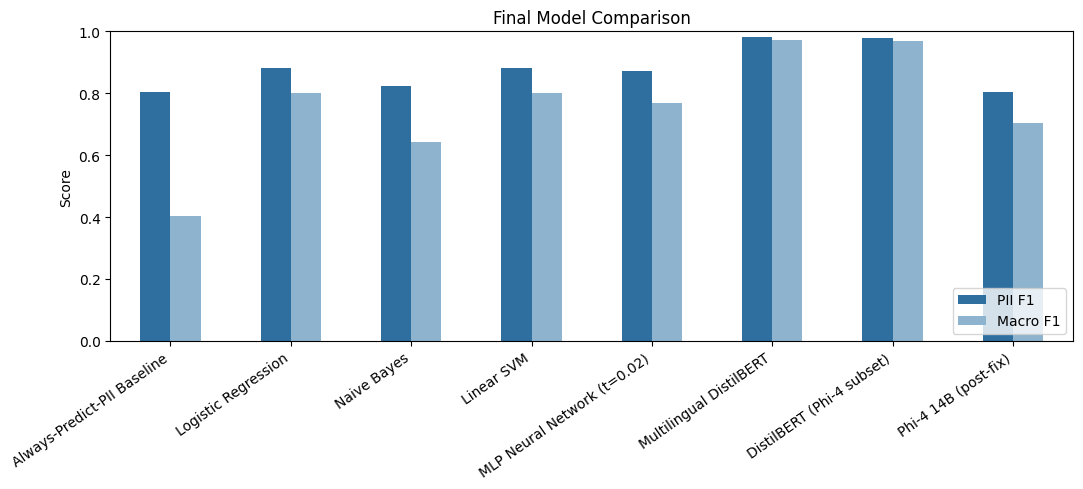

In [8]:
# compare the two balanced summary measures for models with available results
plot_data = results.dropna(subset=["PII F1", "Macro F1"]).copy()
plot_data.plot(
    x="Model",
    y=["PII F1", "Macro F1"],
    kind="bar",
    figsize=(11, 5),
    ylim=(0, 1.0),
    color=["#2f6f9f", "#8db3cf"],
)
plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The scorecard below uses color scaling to make differences across models and evaluation metrics easy to compare at a glance. However, its headline results use different evaluation sizes: Phi-4 was evaluated on a 3,000-row subset, while the other headline models were evaluated on the full 32,543-row test set. The results table above provides the more controlled comparison between Phi-4 and DistilBERT on the exact same 3,000 examples.

The figure is generated in the [06 Evaluation and Error Analysis Dashboard](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb) and saved in `notebooks/figures/`.

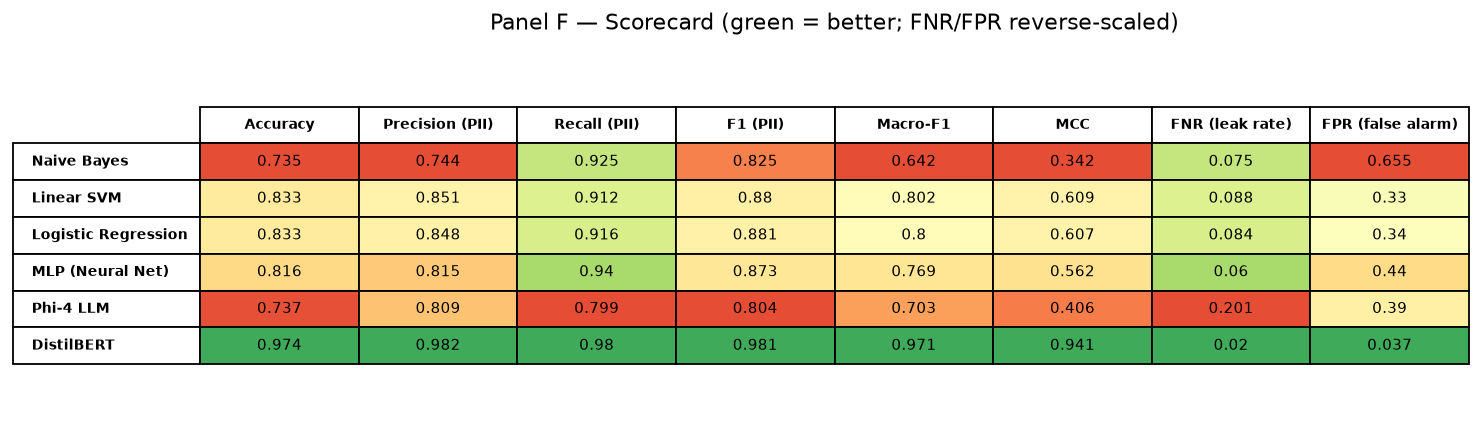

In [9]:
# embed the committed model-performance scorecard from 06
from IPython.display import Image, display as idisplay

fig_name = "panelF_scorecard.png"
fig_path = repo_root / "notebooks" / "figures" / fig_name

if fig_path.exists():
    idisplay(Image(filename=str(fig_path)))
else:
    print(f"{fig_name} not found, run 06_pii_evaluation_error.ipynb to regenerate it.")

The always-predict-PII baseline demonstrates why recall cannot be evaluated in isolation. Although it detects every PII example, it also incorrectly rejects every safe example. The tuned classical models offer a much more practical balance, achieving a PII F1 of approximately 0.88 with recall between 0.91 and 0.92. Among the non-transformer models, the MLP produced the fewest missed PII examples at its selected operating point, with 1,324 false negatives. Multilingual DistilBERT delivered the strongest overall performance.

To ensure a controlled comparison with Phi-4, DistilBERT was also evaluated on the exact 3,000 examples used for the Phi-4 evaluation. On this shared subset, DistilBERT achieved approximately 0.98 recall and 0.98 precision, compared with Phi-4’s 0.80 recall and 0.81 precision after its prompt revision. Because both models were tested on identical examples, the approximately 18-percentage-point difference in recall reflects a direct performance gap rather than differences between evaluation samples. The controlled comparison is saved in `results/distilbert_on_phi4_subset.csv`.

## 12. Response Time per Prompt

A privacy-screening tool must classify a prompt quickly enough to avoid interrupting the user’s workflow. We therefore measured end-to-end latency from raw text to model output, including feature extraction or tokenization where applicable. The benchmark used 100 prompts sampled from the held-out test set with seed 42. Prompts were processed individually, and initial warm-up time was excluded.

The classical and MLP measurements include their complete feature pipelines, DistilBERT includes tokenization and inference, and Phi-4 includes the local Ollama request and response. Because latency varies with hardware and system load, these results should be interpreted as a comparison under the project’s benchmark conditions rather than guaranteed deployment speeds.

In [10]:
# Response-time table from the shared benchmark file (plus the MLP forward-only reference row).
lat = pd.read_csv(repo_root / "results" / "latency_benchmark.csv")
lat["model"] = lat["model"].replace({"Phi-4": "Phi-4 14B"})
lat = lat.rename(columns={"model": "Model", "n": "N prompts", "mean_ms": "Avg ms/prompt",
                          "median_ms": "Median ms/prompt", "min_ms": "Min ms/prompt", "max_ms": "Max ms/prompt"})
lat["Scope"] = "end-to-end"

# forward-only reference row (optional: mlp_latency_benchmark.csv was merged into the
# shared file and may no longer exist -- the table renders fine without it)
_fwd_path = repo_root / "results" / "mlp_latency_benchmark.csv"
frames = [lat]
if _fwd_path.exists():
    fwd = pd.read_csv(_fwd_path)
    fwd = fwd[fwd["stage"] == "MLP forward only"].rename(columns={
        "stage": "Model", "n": "N prompts", "avg_ms_per_prompt": "Avg ms/prompt",
        "median_ms_per_prompt": "Median ms/prompt", "min_ms_per_prompt": "Min ms/prompt",
        "max_ms_per_prompt": "Max ms/prompt"})
    fwd["Model"] = "MLP (forward pass only)"
    fwd["Scope"] = "model-only reference"
    frames.append(fwd)

latency_table = (pd.concat(frames, ignore_index=True)
                   .sort_values("Avg ms/prompt")
                   .round({"Avg ms/prompt": 2, "Median ms/prompt": 2, "Min ms/prompt": 2, "Max ms/prompt": 2}))
display(latency_table[["Model", "Scope", "N prompts", "Avg ms/prompt", "Median ms/prompt", "Min ms/prompt", "Max ms/prompt"]])

_ph = latency_table.set_index("Model")["Avg ms/prompt"]
print(f"Phi-4 is ~{_ph.get('Phi-4 14B', float('nan'))/_ph.get('DistilBERT', float('nan')):,.0f}x slower per prompt than DistilBERT "
      f"and ~{_ph.get('Phi-4 14B', float('nan'))/_ph.get('Logistic Regression', float('nan')):,.0f}x slower than Logistic Regression.")


,Model,Scope,N prompts,Avg ms/prompt,Median ms/prompt,Min ms/prompt,Max ms/prompt
6,MLP (forward pass only),model-only reference,100,0.44,0.33,0.24,2.64
4,Linear SVM,end-to-end,100,1.51,1.51,1.47,1.58
2,Logistic Regression,end-to-end,100,1.55,1.54,1.49,1.72
3,Naive Bayes,end-to-end,100,1.69,1.68,1.62,1.77
5,MLP (Neural Net),end-to-end,100,2.19,2.07,1.75,4.38
0,DistilBERT,end-to-end,100,2.40,2.30,2.10,7.50
1,Phi-4 14B,end-to-end,100,688.80,736.00,174.30,1564.90


Phi-4 is ~287x slower per prompt than DistilBERT and ~444x slower than Logistic Regression.


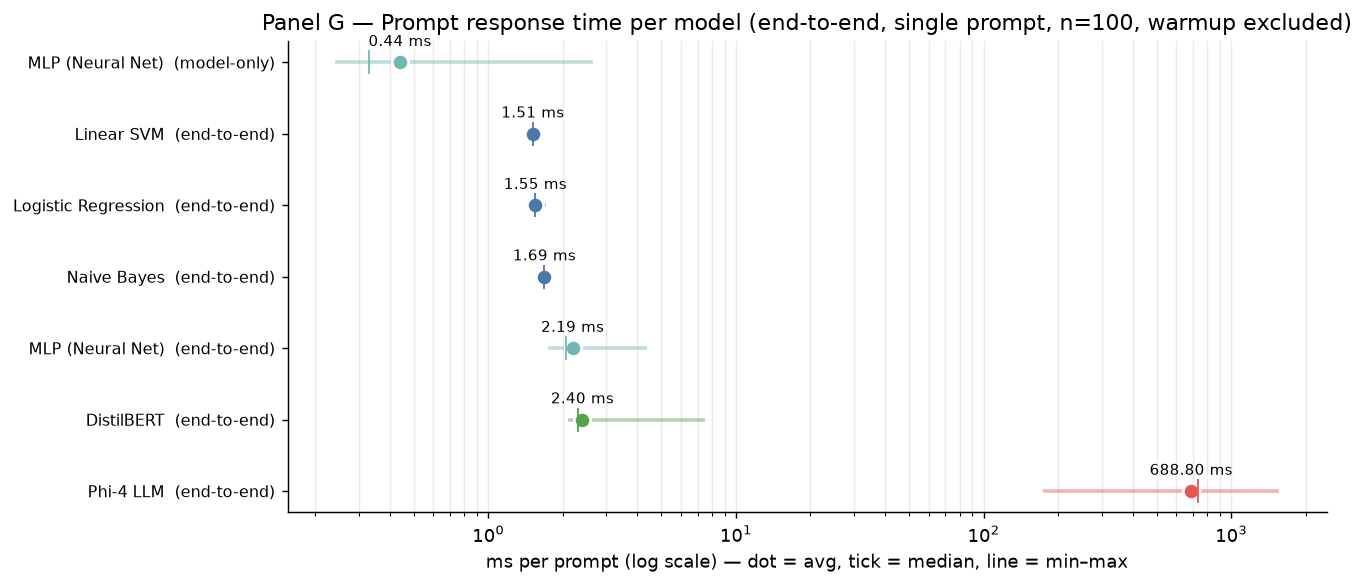

In [11]:
# embed the committed response-time figure from 06
from IPython.display import Image, display as idisplay

fig_name = "panelG_latency.png"
fig_path = repo_root / "notebooks" / "figures" / fig_name

if fig_path.exists():
    idisplay(Image(filename=str(fig_path)))
else:
    print(f"{fig_name} not found, run 06_pii_evaluation_error.ipynb to regenerate it.")

Under the project’s benchmark conditions, the specialized models averaged approximately 1.5 to 2.4 milliseconds per prompt. Phi-4 averaged approximately 689 milliseconds and showed considerably more variation, with individual responses ranging from about 174 to 1,565 milliseconds.

These results indicate that Logistic Regression, Naive Bayes, Linear SVM, the MLP, and DistilBERT could all support low-latency screening in an interactive workflow. Phi-4 was approximately 287 times slower than DistilBERT and 444 times slower than Logistic Regression in this benchmark, making it substantially less practical for inline screening. Although the exact timing would change across hardware and deployment environments, the difference between the specialized models and the general-purpose LLM baseline is clear.

Additional latency results are available in the [06 Evaluation and Error Analysis Dashboard](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb).

## 13. Error Analysis

Overall performance shows which models worked best, but the errors explain why. In a pre-submission privacy screen, a false negative allows PII to pass undetected, while a false positive interrupts a safe prompt. The models produced different error patterns rather than simply making more or fewer versions of the same mistake.

The counts below use the full 32,543-row test set for the specialized models and Phi-4’s 3,000-row evaluation subset.

| Model                              | Primary false-negative pattern                                                                                           | Primary false-positive pattern                                                             | Practical interpretation                                                                                                |
| ---------------------------------- | ------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------- |
| Logistic Regression and Linear SVM | Implicit PII, multilingual prose, and unusually formatted identifiers without strong vocabulary or pattern cues          | Safe prompts containing dates, long numbers, URLs, or address-related terms                | Sparse features detect familiar forms well but struggle when identification depends on context                          |
| Naive Bayes                        | 1,650 missed PII examples, the lowest count among the classical models                                                   | 6,959 false positives, incorrectly flagging approximately 66% of safe prompts              | Higher recall was achieved by over-flagging, making the model difficult to use as an inline screen                      |
| MLP at 0.02                        | 1,324 missed PII examples; misses were generally shorter and less likely to contain obvious formatting cues              | 4,673 false positives                                                                      | The recall-focused threshold reduced leaks but created substantial user friction                                        |
| DistilBERT                         | 447 missed PII examples, often involving dense numeric strings or masking placeholders without clear surrounding context | 394 false positives, including real-looking financial and vehicle identifiers labeled safe | Contextual embeddings substantially reduced both error types, although ambiguous ground truth still affected evaluation |
| Phi-4                              | 406 missed PII examples on its subset, including titled names, subtle disclosures, structured IDs, and non-English text  | 382 false positives, especially generic business URLs                                      | The prompted LLM remained sensitive to wording, taxonomy boundaries, and prompt design                                  |

Phi-4’s targeted placeholder instruction reduced false positives from 547 to 382 and improved macro F1 from approximately 0.65 to 0.70. However, false negatives increased by 80. The revision therefore changed the model’s operating tradeoff rather than improving every type of error.

### 13.1 Representative Misses

All examples below are synthetic by construction and have been truncated.

The lightweight models shared a blind spot for identifiers embedded in ordinary prose. Logistic Regression, Linear SVM, and the MLP all missed examples containing:

* A wallet-style address placed inside Spanish contract language: `3bAYGvHOhwLkOb…`
* A person’s name paired with a personal URL but no numeric pattern
* A national-ID-shaped code embedded in narrative text: `Z7993943C`
* A spaced IBAN inside a French transaction description: `CH 1811 5439 …`

DistilBERT’s remaining misses followed a different pattern. They commonly contained dense or separated numbers without a nearby label explaining what the number represented, such as:

* An access protocol followed by `5587290147`
* A performance-metrics instruction containing `31213457238903216`
* An OTP written with an internal space as `7 6708`

These examples show the central feature-engineering limitation. Surface patterns help when an identifier has a recognizable form, but contextual understanding is needed when PII is embedded in natural language or resembles an ordinary number.

### 13.2 Leak Rate by Language

The table reports the percentage of true-PII prompts that each model failed to detect. Language was assigned using a heuristic rather than verified language labels, so these results should be treated as diagnostic evidence rather than a formal fairness evaluation.

| Heuristic language group | Logistic Regression | Naive Bayes | Linear SVM | MLP at 0.02 | DistilBERT |
| ------------------------ | ------------------: | ----------: | ---------: | ----------: | ---------: |
| French                   |                8.7% |       11.2% |       8.9% |        6.5% |   **1.6%** |
| English                  |                8.7% |        2.7% |       8.9% |        6.9% |   **2.8%** |
| German                   |                8.1% |        6.4% |       8.6% |        5.5% |   **2.5%** |
| Spanish                  |                8.8% |       12.7% |      10.0% |        5.5% |   **1.8%** |
| Italian                  |                7.2% |       12.6% |       7.6% |        5.1% |   **1.3%** |
| Dutch                    |               10.8% |        3.0% |      10.5% |        6.9% |   **2.1%** |
| Other or unknown         |                7.6% |        2.8% |       8.2% |        5.1% |   **1.9%** |

Logistic Regression and Linear SVM produced relatively consistent leak rates across languages, but neither fell below 7%. Naive Bayes varied substantially, from 2.7% for English to nearly 13% for Spanish and Italian. The recall-focused MLP improved on the classical models but still missed approximately 5% to 7% of PII within each group. DistilBERT remained below 3% across every group, supporting the decision to use a multilingual checkpoint.

Phi-4 is not included in this table because it was evaluated on a smaller 3,000-row subset rather than the full test set.

The complete calculations and row-level analysis are available in the [06 Evaluation and Error Analysis Dashboard](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb). Additional DistilBERT and Phi-4 analysis is available in [Transformer and LLM Analysis](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/brandon_error_analysis.md).

## 14. Key Project Decisions

The following decisions shaped the validity, comparability, and practical interpretation of the project:

1. **Convert token annotations into document-level labels.** A prompt was classified as privacy-sensitive if it contained at least one dataset-annotated PII token. This matched the intended allow-or-flag screening decision.

2. **Clean the data before creating the final split.** Blank and duplicate text was removed before the stratified split, preventing duplicate examples from appearing across training and evaluation data.

3. **Use one frozen split.** All specialized models used the same seed-42 training, validation, and test sets. Phi-4’s stratified subset was drawn from the frozen test set.

4. **Exclude answer-derived information.** Token labels, masking annotations, and original PII categories were not used as model inputs because they would not be available during real screening and would create data leakage.

5. **Fit transformations using training data only.** TF-IDF vocabularies and numeric scaling were learned from the training split without using validation or test text.

6. **Evaluate the errors that matter for privacy screening.** PII recall and F1 were emphasized alongside false negatives and false positives. Accuracy alone would conceal both missed PII and excessive blocking.

7. **Select operating points using validation evidence.** The classical-model and MLP thresholds were selected through validation analysis. DistilBERT retained its default decision rule after a validation sweep showed negligible change across thresholds.

8. **Use multilingual DistilBERT with a 256-token limit.** The multilingual checkpoint matched the dataset’s language distribution, while 256 tokens covered 99.98% of analyzed examples at lower computational cost than 512 tokens.

9. **Evaluate Phi-4 locally on a stratified subset.** Local inference preserved data locality and made the comparison feasible. DistilBERT was subsequently evaluated on the exact same 3,000 examples to provide a controlled comparison.

10. **Measure complete per-prompt response time.** The latency benchmark included feature extraction or tokenization and model inference, reflecting the delay a user would experience during screening.

11. **Document the Phi-4 prompt revision.** Error analysis motivated a targeted placeholder instruction. Because the revision was developed after examining the evaluation subset, its post-fix result is reported with that limitation rather than treated as performance on a completely untouched test set.

The complete rationale for these choices is recorded in the [Decision Log](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/decisions.md).

## 15. Discussion and Limitations

### Discussion

The results support the project’s central hypothesis: a model trained specifically for PII screening can outperform a prompted general-purpose LLM on this task. Multilingual DistilBERT achieved the strongest detection quality, indicating that contextual and multilingual representations are valuable when PII appears in varied languages, formats, and surrounding prose.

The lighter models still provide useful alternatives. Logistic Regression and Linear SVM achieved PII F1 scores near 0.88 with simple sparse-feature pipelines. The MLP’s recall-focused threshold reduced false negatives to 1,324, but it also produced 4,673 false positives. Naive Bayes similarly increased recall by flagging approximately two-thirds of safe prompts. These results demonstrate that maximizing detection without considering false alarms does not produce a practical screening system.

Under the project’s benchmark conditions, all specialized models averaged approximately 1.5 to 2.4 milliseconds per prompt, compared with approximately 689 milliseconds for Phi-4. These measurements show that specialized screening can operate within an interactive workflow. They do not prove identical performance in every environment, particularly because DistilBERT was benchmarked with local GPU acceleration while the classical models can run on a CPU.

### Limitations

* **Narrow target definition:** The label represents dataset-annotated PII, not every type of sensitive information. The models were not trained to detect source code, trade secrets, credentials, or confidential business information.

* **Synthetic and masked data:** The dataset contains synthetic text, masking placeholders, and structured formatting that may differ from real employee prompts. Models may have learned patterns that will not transfer fully to production data.

* **Ground-truth ambiguity:** Some examples labeled safe contain identifiers that appear genuinely sensitive, including financial, vehicle, and business-related identifiers. This makes some apparent false positives difficult to interpret.

* **Unequal evaluation sizes:** Phi-4 was evaluated on a 3,000-row subset, while the specialized models were evaluated on the full 32,543-row test set. The controlled DistilBERT comparison addresses this issue for the two transformer models, but the classical models and MLP have not been evaluated separately on the shared subset.

* **Prompt revision on evaluation data:** Phi-4’s placeholder instruction was developed after reviewing errors from its evaluation subset and then tested on that same subset. The post-fix results may therefore be optimistic and should be confirmed on untouched data.

* **Heuristic language analysis:** Language groups were inferred from text rather than supplied as verified labels. The analysis identifies useful patterns but is not a definitive language-performance or fairness evaluation.

* **Limited error breakdown:** Performance was not fully measured by individual PII category, and the project did not test systematically obfuscated identifiers.

* **Hardware-specific latency:** Response times reflect the project’s local hardware and software configuration. Production latency would depend on device capabilities, concurrency, batching, and system load.

* **No production validation:** The project did not measure real user behavior, alert fatigue, adversarial input, data drift, or integration with an operational LLM gateway.

Before deployment, the selected model would require validation on organization-specific prompts, recalibration of its warning or blocking threshold, broader sensitive-data coverage, and ongoing monitoring for changes in language and input patterns.

## 16. Conclusion

This project asked whether privacy-sensitive prompts could be detected before they reach an external LLM and whether a purpose-built classifier would be more effective than using a general-purpose LLM for that decision. Within this dataset-defined task, the answer is yes.

The strongest evidence comes from the controlled comparison on the exact same 3,000 prompts. Multilingual DistilBERT achieved a PII F1 of approximately 0.979 and missed 41 PII examples. Phi-4 achieved a PII F1 of approximately 0.804 and missed 406. Under the project’s latency benchmark, DistilBERT averaged 2.4 milliseconds per prompt, compared with 688.8 milliseconds for Phi-4, making Phi-4 approximately 287 times slower.

On the full 32,543-row test set, DistilBERT maintained a PII F1 of approximately 0.981, with 447 false negatives and 394 false positives. It is therefore the recommended model when detection quality is the primary goal and local GPU inference is available. Tuned Logistic Regression remains a credible CPU-friendly alternative, reaching a PII F1 of 0.881 and recall of 0.916 with an average response time of approximately 1.55 milliseconds. The MLP offers higher recall when missed PII is the overriding concern, but its additional false positives would create more user friction.

The result is not that one model is universally better. It is that model fit matters. For multilingual, document-level PII screening, the best-performing approach was not the largest general-purpose model; it was a smaller model trained specifically for the task.

That finding makes the proposed control practical: screen each prompt locally in milliseconds, warn or block when likely PII is detected, and intervene before sensitive information leaves the organization.

## Supporting Notebooks

1. [01 Data EDA](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/01_data_eda.ipynb)
2. [02 Feature Engineering](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/02_feature_engineering.ipynb)
3. [03 Classical Models](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/03_classical_models.ipynb)
4. [04 Neural Network](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/04_neural_net.ipynb)
5. [05 DistilBERT](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/05_distilbert.ipynb)
6. [06 Evaluation and Error Analysis Dashboard](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/notebooks/06_pii_evaluation_error.ipynb)
7. [Transformer and LLM Analysis](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/brandon_error_analysis.md)
8. [Decision Log](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison/blob/main/docs/decisions.md)

## Project Repository

[Cyber-207/cyber207_specialized_PII_detection_comparison](https://github.com/Cyber-207/cyber207_specialized_PII_detection_comparison)